In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Analyse descriptive

In [2]:

# Chargement du dataset

path = "finance_dataset_25000_with_qualitative.csv"

df = pd.read_csv(path, sep=";")

# Affichage des premières lignes pour inspection visuelle
print("Aperçu des données :")
display(df.head())

# Affichage des informations structurelles
print("\nStructure du dataset :")
df.info()

# Vérification du nombre d'observations et de variables
print(
    f"\nDimensions du dataset : {df.shape[0]} observations et {df.shape[1]} variables."
)

Aperçu des données :


,inflation,interest_rate,gdp_growth,unemployment,volatility_index,revenue,debt,assets,equity,cash_flow,...,bid_ask_spread,var_95,expected_shortfall,credit_spread,sector,rating_category,region,listing_market,audit_quality,market_price
0,2.248357,3.170874,2.598206,4.682337,25.152973,30750.388277,7776.911715,48675.416046,44022.185756,6081.096195,...,0.020764,-0.020989,NaN,2.130494,NaN,A,Asia,NASDAQ,MidTier,0.260318
1,1.930868,3.012255,2.435892,6.928322,14.223226,19912.844477,2763.392640,48773.753408,45821.904144,4054.805180,...,0.017154,-0.049048,-0.117033,1.355923,Healthcare,BBB,North_America,NYSE,MidTier,0.596085
2,2.323844,2.568845,3.451791,4.306710,22.877186,15921.440028,1396.660290,43344.387490,39288.656004,NaN,...,0.020268,-0.066862,-0.082338,1.109062,Industry,AAA,North_America,NYSE,MidTier,NaN
3,2.761515,2.997473,4.032831,7.736176,NaN,41403.623699,7898.061038,72571.120931,61895.783628,7743.847722,...,NaN,-0.057502,-0.069842,1.255731,Healthcare,A,North_America,LSE,MidTier,NaN
4,1.882923,3.490842,3.186847,4.878280,NaN,39917.130613,2753.907879,60414.547942,56975.338500,6949.078097,...,0.022232,-0.046187,-0.105883,1.975884,Technology,BBB,Europe,HKEX,Big4,0.455834



Structure du dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   inflation           22954 non-null  float64
 1   interest_rate       22942 non-null  float64
 2   gdp_growth          23024 non-null  float64
 3   unemployment        23003 non-null  float64
 4   volatility_index    22986 non-null  float64
 5   revenue             22992 non-null  float64
 6   debt                23049 non-null  float64
 7   assets              22983 non-null  float64
 8   equity              23040 non-null  float64
 9   cash_flow           23026 non-null  float64
 10  roa                 22976 non-null  float64
 11  roe                 22989 non-null  float64
 12  eps                 23011 non-null  float64
 13  pe_ratio            23082 non-null  float64
 14  market_beta         22967 non-null  float64
 15  dividend_yield      23036 non

Le dataset contient 31 variables et 25000 observations.

Toutes les variables ont des données manquantes.

Les colonnes 0 à 24 correspondent à des variables numériques continues.

Les colonnes 25 à 29 sont des variables qualitatives non numériques.

La variable dépendante correspond à la colonne 30.

In [3]:

# 2. Statistiques descriptives globales
# Affichage des statistiques pour les variables numériques
stats_num = df.describe()
print("Statistiques descriptives (numériques) :")
print(stats_num)

# Affichage des statistiques pour les variables catégorielles
stats_cat = df.describe(include=['object'])
print("\nStatistiques descriptives (catégorielles) :")
print(stats_cat)


Statistiques descriptives (numériques) :
          inflation  interest_rate    gdp_growth  unemployment  \
count  22954.000000   22942.000000  23024.000000  23003.000000   
mean       1.998373       3.003064      2.504490      5.999400   
std        0.499422       1.003234      0.998813      1.502547   
min        0.038800      -1.465604     -1.657734     -0.694453   
25%        1.661496       2.321947      1.826057      5.000692   
50%        1.999367       3.006079      2.509756      6.001142   
75%        2.336108       3.685908      3.179248      7.008648   
max        3.971166       6.727833      6.260155     11.744673   

       volatility_index        revenue          debt         assets  \
count      22986.000000   22992.000000  23049.000000   22983.000000   
mean          20.006812   26447.062859   3802.096750   41080.931715   
std            5.000279   17271.423932   3000.838330   21814.073732   
min            0.003339    2260.220234    226.619440    4076.436996   
25%      

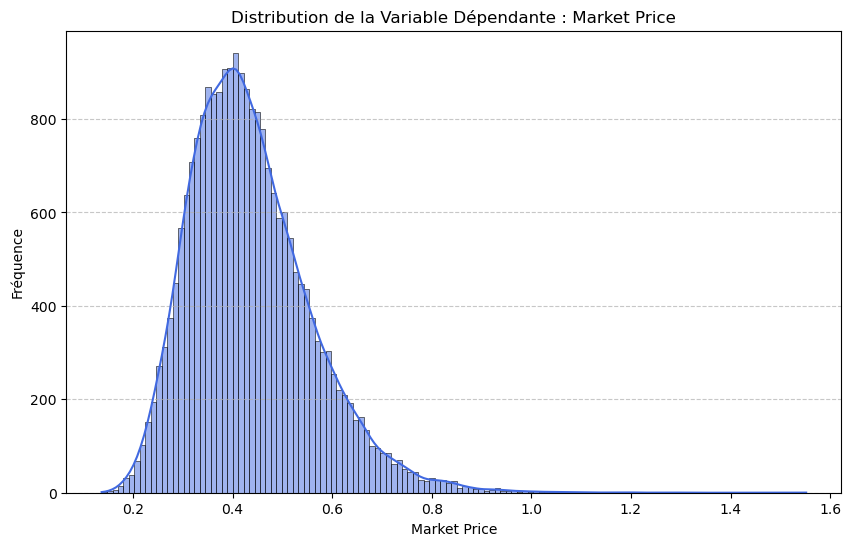

In [4]:
# 3. Distribution de la variable dépendante (market_price)
plt.figure(figsize=(10, 6))
sns.histplot(df['market_price'], kde=True, color='royalblue')
plt.title('Distribution de la Variable Dépendante : Market Price')
plt.xlabel('Market Price')
plt.ylabel('Fréquence')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Analyse des valeurs manquantes :


,Total,Pourcentage (%)
interest_rate,2058,8.232
sector,2052,8.208
inflation,2046,8.184
volume,2043,8.172
audit_quality,2040,8.160
market_beta,2033,8.132
region,2025,8.100
roa,2024,8.096
credit_spread,2020,8.080
assets,2017,8.068


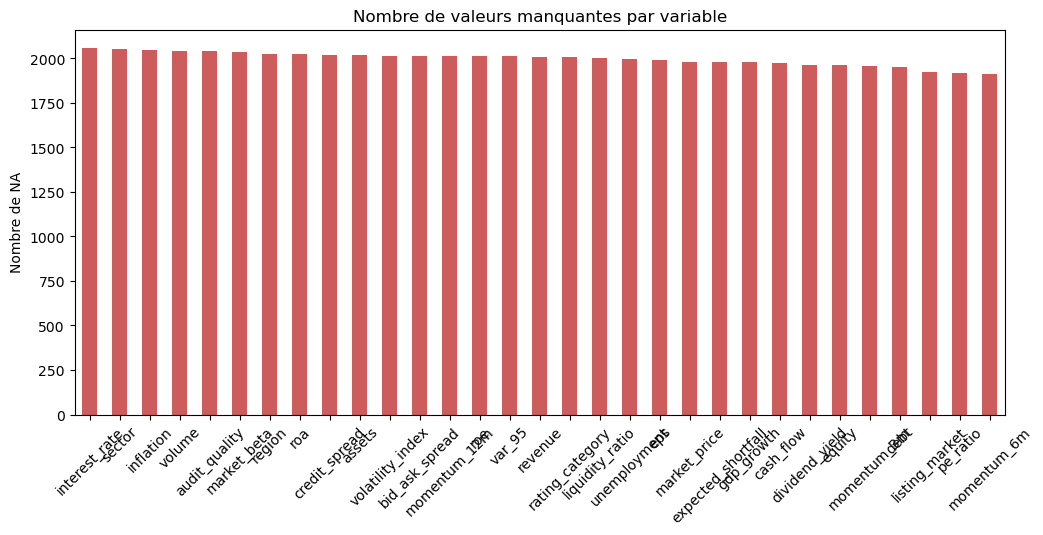

In [5]:
# 4. Analyse des valeurs manquantes
# Calcul du total et du pourcentage de valeurs manquantes par colonne
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = pd.concat([missing_count, missing_percent], axis=1, keys=['Total', 'Pourcentage (%)'])

# Affichage des variables ayant au moins une valeur manquante
print("\nAnalyse des valeurs manquantes :")
display(missing_table[missing_table['Total'] > 0].sort_values(by='Total', ascending=False))

# Visualisation des valeurs manquantes
plt.figure(figsize=(12, 5))
missing_count[missing_count > 0].sort_values(ascending=False).plot(kind='bar', color='indianred')
plt.title('Nombre de valeurs manquantes par variable')
plt.ylabel('Nombre de NA')
plt.xticks(rotation=45)
plt.show()

La variable dépendante , le market price semble à première vue être distribuée selon une loi normale, centrée autour de sa moyenne (0.435952).

Cependant, on voit que la queue de distribution droite est plus grande que celle de gauche. La distribution est donc asymétrique.

On constate d'ailleurs que la moyenne est plus grande que la médiane (0.419482)


On voit également que chaque variable à entre 7,6% et 8,2% de ses valeurs manquantes, il faudra donc traiter ces dernières.


In [6]:
df.columns

Index(['inflation', 'interest_rate', 'gdp_growth', 'unemployment',
       'volatility_index', 'revenue', 'debt', 'assets', 'equity', 'cash_flow',
       'roa', 'roe', 'eps', 'pe_ratio', 'market_beta', 'dividend_yield',
       'momentum_3m', 'momentum_6m', 'momentum_12m', 'volume',
       'liquidity_ratio', 'bid_ask_spread', 'var_95', 'expected_shortfall',
       'credit_spread', 'sector', 'rating_category', 'region',
       'listing_market', 'audit_quality', 'market_price'],
      dtype='object')

# 2. Préparation des données

Pour traiter les valeurs manquantes la méthode la plus simple consiste à simplement supprimer chaque observation qui contient une valeur manquante. On va donc commencer par essayer cette méthode étant donné qu'on a beaucoup de données.

In [7]:
# 1. Traitement des valeurs manquantes par suppression (Listwise Deletion)
# On crée une copie du dataframe original pour conserver les données brutes
df_clean = df.dropna().copy()

# 2. Calcul de l'impact de la suppression
n_original = len(df)
n_final = len(df_clean)
n_supprimees = n_original - n_final
pct_supprimees = (n_supprimees / n_original) * 100

print(f"Nombre d'observations avant suppression : {n_original}")
print(f"Nombre d'observations après suppression : {n_final}")
print(f"Observations supprimées : {n_supprimees} ({pct_supprimees:.2f}%)")

# 3. Vérification rapide qu'il ne reste aucun NA
print("\nVérification des valeurs manquantes restantes :")
print(df_clean.isnull().sum().sum())

Nombre d'observations avant suppression : 25000
Nombre d'observations après suppression : 1922
Observations supprimées : 23078 (92.31%)

Vérification des valeurs manquantes restantes :
0


On constate que 23 078, observations sur les 25 000 ont été supprimés. Si on utilise cette méthode, on supprime donc quasiment toutes les données, on ne peut pas utiliser cette méthode.

Une autre méthode pour traiter les données manquantes consiste à imputer les valeurs numériques par leur médiane et les valeurs catégoriel par leur mode.

In [8]:
# 1. Traitement des valeurs manquantes par imputation

# Identification des colonnes par type
cols_num = df.select_dtypes(include=[np.number]).columns
cols_cat = df.select_dtypes(include=['object']).columns

# Imputation des variables numériques par la médiane (plus robuste aux outliers que la moyenne)
imputer_num = SimpleImputer(strategy='median')
df[cols_num] = imputer_num.fit_transform(df[cols_num])

# Imputation des variables qualitatives par le mode (la valeur la plus fréquente)
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cols_cat] = imputer_cat.fit_transform(df[cols_cat])

# Vérification finale
print(f"Nombre de valeurs manquantes restantes : {df.isnull().sum().sum()}")

# 2. Transformation des variables qualitatives (Dummification / One-Hot Encoding)
# On transforme les catégories en variables binaires (0/1)
# drop_first=True permet d'éviter le piège de la multicolinéarité (dummy variable trap)
df_final = pd.get_dummies(df, columns=['sector', 'rating_category', 'region', 
                                       'listing_market', 'audit_quality'], 
                          drop_first=True)

# Affichage des nouvelles dimensions
print(f"Dimensions après transformation : {df_final.shape}")

Nombre de valeurs manquantes restantes : 0
Dimensions après transformation : (25000, 42)


In [9]:
df.head()

,inflation,interest_rate,gdp_growth,unemployment,volatility_index,revenue,debt,assets,equity,cash_flow,...,bid_ask_spread,var_95,expected_shortfall,credit_spread,sector,rating_category,region,listing_market,audit_quality,market_price
0,2.248357,3.170874,2.598206,4.682337,25.152973,30750.388277,7776.911715,48675.416046,44022.185756,6081.096195,...,0.020764,-0.020989,-0.070303,2.130494,Finance,A,Asia,NASDAQ,MidTier,0.260318
1,1.930868,3.012255,2.435892,6.928322,14.223226,19912.844477,2763.392640,48773.753408,45821.904144,4054.805180,...,0.017154,-0.049048,-0.117033,1.355923,Healthcare,BBB,North_America,NYSE,MidTier,0.596085
2,2.323844,2.568845,3.451791,4.306710,22.877186,15921.440028,1396.660290,43344.387490,39288.656004,5991.295839,...,0.020268,-0.066862,-0.082338,1.109062,Industry,AAA,North_America,NYSE,MidTier,0.419482
3,2.761515,2.997473,4.032831,7.736176,20.022101,41403.623699,7898.061038,72571.120931,61895.783628,7743.847722,...,0.019992,-0.057502,-0.069842,1.255731,Healthcare,A,North_America,LSE,MidTier,0.419482
4,1.882923,3.490842,3.186847,4.878280,20.022101,39917.130613,2753.907879,60414.547942,56975.338500,6949.078097,...,0.022232,-0.046187,-0.105883,1.975884,Technology,BBB,Europe,HKEX,Big4,0.455834


On regarde quels sont les modalités des variables catégorielles pour pouvoir les traiter de manière appropriée.

In [10]:
# 1. Identification des variables qualitatives (catégorielles)
cols_cat = ['sector', 'rating_category', 'region', 'listing_market', 'audit_quality']

# 2. Extraction et affichage des modalités uniques pour chaque variable
print("Liste des modalités par variable catégorielle :")
print("-" * 50)

for col in cols_cat:
    modalites = df[col].unique()
    nb_modalites = df[col].nunique()
    print(f"Variable : {col} ({nb_modalites} modalités)")
    print(f"Valeurs : {modalites}")
    print("-" * 50)

Liste des modalités par variable catégorielle :
--------------------------------------------------
Variable : sector (5 modalités)
Valeurs : ['Finance' 'Healthcare' 'Industry' 'Technology' 'Energy']
--------------------------------------------------
Variable : rating_category (5 modalités)
Valeurs : ['A' 'BBB' 'AAA' 'AA' 'BB']
--------------------------------------------------
Variable : region (4 modalités)
Valeurs : ['Asia' 'North_America' 'Europe' 'Emerging']
--------------------------------------------------
Variable : listing_market (4 modalités)
Valeurs : ['NASDAQ' 'NYSE' 'LSE' 'HKEX']
--------------------------------------------------
Variable : audit_quality (3 modalités)
Valeurs : ['MidTier' 'Big4' 'Local']
--------------------------------------------------


Comme les variables catégorie, on entre trois et cinq modalités. On va utiliser des dummies en faisant attention à toujours supprimer la devise de la référence.


In [11]:
# 1. Transformation des variables qualitatives en variables dummies
# Liste des colonnes catégorielles identifiées précédemment
cols_cat = ['sector', 'rating_category', 'region', 'listing_market', 'audit_quality']

# Création des dummies avec suppression de la modalité de référence
# drop_first=True : Supprime la première modalité alphabétique pour chaque variable
df_final = pd.get_dummies(df, columns=cols_cat, drop_first=True, dtype=int)

# 2. Visualisation de la structure du nouveau dataset
print(f"Nombre de colonnes initial : {df.shape[1]}")
print(f"Nombre de colonnes après dummification : {df_final.shape[1]}")

# Affichage des nouvelles colonnes créées
print("\nNouvelles colonnes (Dummies) :")
print([col for col in df_final.columns if any(cat in col for cat in cols_cat)])

# 3. Vérification de l'absence de valeurs manquantes avant la modélisation
print(f"\nNombre total de valeurs manquantes : {df_final.isnull().sum().sum()}")

Nombre de colonnes initial : 31
Nombre de colonnes après dummification : 42

Nouvelles colonnes (Dummies) :
['sector_Finance', 'sector_Healthcare', 'sector_Industry', 'sector_Technology', 'rating_category_AA', 'rating_category_AAA', 'rating_category_BB', 'rating_category_BBB', 'region_Emerging', 'region_Europe', 'region_North_America', 'listing_market_LSE', 'listing_market_NASDAQ', 'listing_market_NYSE', 'audit_quality_Local', 'audit_quality_MidTier']

Nombre total de valeurs manquantes : 0


In [12]:

# 1. Définition de la variable cible (y) et des prédicteurs (X)
X = df_final.drop(columns=['market_price'])
y = df_final['market_price']

# 2. Séparation en ensembles d'entraînement (80%) et de test (20%)
# random_state=42 assure la reproductibilité des résultats
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Affichage des dimensions pour vérification
print(f"Dimensions de l'ensemble d'entraînement : {X_train.shape}")
print(f"Dimensions de l'ensemble de test : {X_test.shape}")


Dimensions de l'ensemble d'entraînement : (20000, 41)
Dimensions de l'ensemble de test : (5000, 41)


# 3. Modélisation économétrique

In [13]:
# 1. Ajout de la constante (intercept) pour l'ensemble d'entraînement et de test
# Statsmodels ne l'ajoute pas automatiquement, contrairement à scikit-learn

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# 2. Estimation du modèle de régression linéaire (OLS) sur l'ensemble Train
model = sm.OLS(y_train, X_train_const.astype(float))
results = model.fit()

# 3. Affichage du résumé statistique complet
print(results.summary())

# 4. Calcul des prédictions sur l'ensemble Test pour évaluation future
y_pred_ols = results.predict(X_test_const)

                            OLS Regression Results                            
Dep. Variable:           market_price   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     1189.
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               0.00
Time:                        11:31:44   Log-Likelihood:                 26835.
No. Observations:               20000   AIC:                        -5.359e+04
Df Residuals:                   19958   BIC:                        -5.325e+04
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.77


### Commentaire des coefficients

Le modèle présente une forte capacité explicative avec un R2de 0.71.
- Variables Significatives (p < 0.05) : volatility_index, revenue, roa, roe, eps, 
  momentum_12m, var_95, credit_spread, ainsi que les secteurs et notations de crédit.
- Variables Non Significatives : Les variables macro (gdp_growth, interest_rate) 
  et de structure brute (assets, debt, cash_flow) n'impactent pas directement le prix ici.
- Multicolinéarité : Le Condition Number élevé suggère une corrélation entre 
  certaines variables (ex: ROA et ROE), ce qui peut fragiliser la précision des coefficients.


### Interprétation économique

1. Prédominance du Risque : La volatilité (coeff -0.02) est le principal moteur 
   baissier. Une hausse de l'incertitude ou du risque de défaut (credit_spread) 
   entraîne une correction immédiate du prix de marché.
2. Valorisation par la Rentabilité : Le marché valorise fortement la capacité à 
   générer du profit par action (EPS) et l'efficacité opérationnelle (ROA/ROE).
3. Effet Secteur et Qualité : Le secteur Technology bénéficie d'une prime de 
   valorisation (+0.026). La notation financière (AAA/AA) agit comme un signal 
   de confiance, augmentant mécaniquement le prix par rapport à la catégorie A qui est référence.
4. Absorption Macro : L'absence de significativité du PIB ou du chômage suggère 
   que l'information macro est déjà intégrée dans les variables de marché (volatilité).


# 4. Sélection de variables

### Forward Selection

In [14]:
# Utilisation de X_train et y_train pour éviter le data leakage
def forward_selection(data, target, significance_level=0.05):
    initial_features = data.columns.tolist()
    best_features = []
    
    while len(initial_features) > 0:
        remaining_features = list(set(initial_features) - set(best_features))
        new_pval = pd.Series(index=remaining_features, dtype=float)
        
        for new_column in remaining_features:
            # On ajuste le modèle sur les données d'entraînement
            model = sm.OLS(target, sm.add_constant(data[best_features + [new_column]])).fit()
            new_pval[new_column] = model.pvalues[new_column]
        
        min_p_value = new_pval.min()
        if min_p_value < significance_level:
            best_features.append(new_pval.idxmin())
        else:
            break
            
    return best_features

# 2. Exécution de la sélection Forward sur l'ensemble Train
selected_features_forward = forward_selection(X_train, y_train)

# 3. Affichage des résultats
print(f"Nombre de variables sélectionnées : {len(selected_features_forward)}")
print("\nVariables retenues par Forward Selection :")
print(selected_features_forward)

# 4. Estimation du modèle final avec les variables sélectionnées sur Train
X_train_forward = sm.add_constant(X_train[selected_features_forward])
model_forward = sm.OLS(y_train, X_train_forward).fit()

# 5. Affichage du résumé
print(model_forward.summary())

# 6. Préparation des prédictions sur l'ensemble Test
X_test_forward = sm.add_constant(X_test[selected_features_forward])
y_pred_forward = model_forward.predict(X_test_forward)

Nombre de variables sélectionnées : 16

Variables retenues par Forward Selection :
['volatility_index', 'eps', 'revenue', 'sector_Technology', 'rating_category_AAA', 'credit_spread', 'momentum_12m', 'rating_category_AA', 'sector_Healthcare', 'sector_Finance', 'sector_Industry', 'rating_category_BB', 'roe', 'roa', 'var_95', 'rating_category_BBB']
                            OLS Regression Results                            
Dep. Variable:           market_price   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     3047.
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               0.00
Time:                        11:31:50   Log-Likelihood:                 26827.
No. Observations:               20000   AIC:                        -5.362e+04
Df Residuals:                   19983   BIC:                        -5.349e+04
Df Model:           

### Backward sélection

In [15]:
# 1. Préparation des données
y = df_final['market_price']
X = sm.add_constant(df_final.drop(columns=['market_price']))

def backward_selection(data, target, significance_level=0.05):
    features = data.columns.tolist()
    
    while len(features) > 0:
        # Estimation du modèle avec les variables actuelles
        model = sm.OLS(target, data[features].astype(float)).fit()
        
        # Extraction des p-values (en excluant la constante de la suppression si souhaité)
        # Ici on permet la suppression de la constante si elle n'est pas significative
        p_values = model.pvalues
        max_p_value = p_values.max()
        
        if max_p_value > significance_level:
            excluded_feature = p_values.idxmax()
            features.remove(excluded_feature)
            # print(f"Suppression de {excluded_feature} (p-value: {max_p_value:.4f})")
        else:
            break
            
    return features

# 2. Exécution de la sélection Backward
selected_features_backward = backward_selection(X, y)

# 3. Affichage des résultats
print(f"Nombre de variables conservées : {len(selected_features_backward)}")
print("\nVariables retenues par Backward Selection :")
print(selected_features_backward)

# 4. Estimation du modèle final
model_backward = sm.OLS(y, X[selected_features_backward]).fit()
print(model_backward.summary())

Nombre de variables conservées : 17

Variables retenues par Backward Selection :
['const', 'volatility_index', 'revenue', 'roa', 'roe', 'eps', 'momentum_12m', 'var_95', 'credit_spread', 'sector_Finance', 'sector_Healthcare', 'sector_Industry', 'sector_Technology', 'rating_category_AA', 'rating_category_AAA', 'rating_category_BB', 'rating_category_BBB']
                            OLS Regression Results                            
Dep. Variable:           market_price   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     3812.
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               0.00
Time:                        11:31:51   Log-Likelihood:                 33519.
No. Observations:               25000   AIC:                        -6.700e+04
Df Residuals:                   24983   BIC:                        -6.686e+04
Df Model:    

### Lasso

In [16]:

# 1. Normalisation des données (fit sur Train, transform sur Train et Test)
# Le LASSO est sensible à l'échelle des variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Sélection des variables par LASSO avec validation croisée sur le Train
lasso = LassoCV(cv=5, random_state=42).fit(X_train_scaled, y_train)
selected_features_lasso = X_train.columns[lasso.coef_ != 0].tolist()

# 3. Rapport de régression (Post-LASSO OLS) sur l'ensemble Train
# On réestime un OLS non biaisé sur les variables sélectionnées
X_train_post_lasso = sm.add_constant(X_train[selected_features_lasso])
model_post_lasso = sm.OLS(y_train, X_train_post_lasso.astype(float)).fit()

# 4. Affichage du résumé
print(f"Nombre de variables sélectionnées par LASSO : {len(selected_features_lasso)}")
print(model_post_lasso.summary())

# 5. Préparation des prédictions sur l'ensemble Test pour comparaison
X_test_post_lasso = sm.add_constant(X_test[selected_features_lasso])
y_pred_lasso = model_post_lasso.predict(X_test_post_lasso)

Nombre de variables sélectionnées par LASSO : 32
                            OLS Regression Results                            
Dep. Variable:           market_price   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     1524.
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               0.00
Time:                        11:31:51   Log-Likelihood:                 26834.
No. Observations:               20000   AIC:                        -5.360e+04
Df Residuals:                   19967   BIC:                        -5.334e+04
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

## Comparaison des variables sélectionnées

Le tableau suivant résume le nombre de variables retenues par chaque méthode :

| Méthode | Nombre de variables | R² Ajusté | Caractéristique de la sélection |
| :--- | :---: | :---: | :--- |
| **Backward** | 17 | 0.709 | Modèle le plus parcimonieux (avec la constante). |
| **Forward** | 16 | 0.709 | Sélection quasi identique au Backward. |
| **LASSO** | 32 | 0.709 | Modèle le plus "gourmand", inclut des variables non significatives. |

### Variables "Core" (Sélectionnées par toutes les méthodes) :
Toutes les méthodes s'accordent sur l'importance cruciale de :
*   **Risque :** `volatility_index`, `var_95`, `credit_spread`.
*   **Performance :** `eps`, `revenue`, `roa`, `roe`.
*   **Marché :** `momentum_12m`.
*   **Qualitatif :** Les 4 secteurs (`Technology`, `Finance`, `Healthcare`, `Industry`) et les 4 catégories de notation (`AAA`, `AA`, `BB`, `BBB`).

---

## Commentaire des différences observées

### Backward et Forward
On remarque que les méthodes **stepwise** (Backward et Forward) ont convergé vers le même set de 16 variables (hors constante). Elles ont éliminé toutes les variables macro (inflation, taux d'intérêt), les variables géographiques, ainsi que les indicateurs de liquidité et d'audit. 
*   **Résultat :** Le modèle gagne énormément en lisibilité sans aucune perte de pouvoir prédictif ($R^2$ identique à 0.709). Le *Condition Number* chute de **52 millions** à **1,6 million**, indiquant une réduction de la multicolinéarité.

### Le comportement spécifique du LASSO
Le LASSO a été beaucoup plus conservateur dans l'élimination. Il a conservé **32 variables**, incluant des variables que l'OLS juge non significatives (p-value > 0.05) comme l'inflation, les taux d'intérêt, ou le momentum à 3 et 6 mois.
*   **Explication :** Le LASSO ne cherche pas la significativité statistique ($p-value$) mais la réduction de l'erreur de prédiction. Il préfère garder une variable avec un coefficient très faible (presque nul) si elle apporte une amélioration marginale à la stabilité du modèle, là où le test de Student ($t-test$) du Backward l'aurait rejetée.

### Conclusion sur la sélection
Les modèles **Backward/Forward** sont préférables ici car ils isolent les "vrais" moteurs du prix tout en conservant un R2 et un R2 ajusté identique.

# 5. Comparaison avec des méthodes d’apprentissage statistique

### KNN

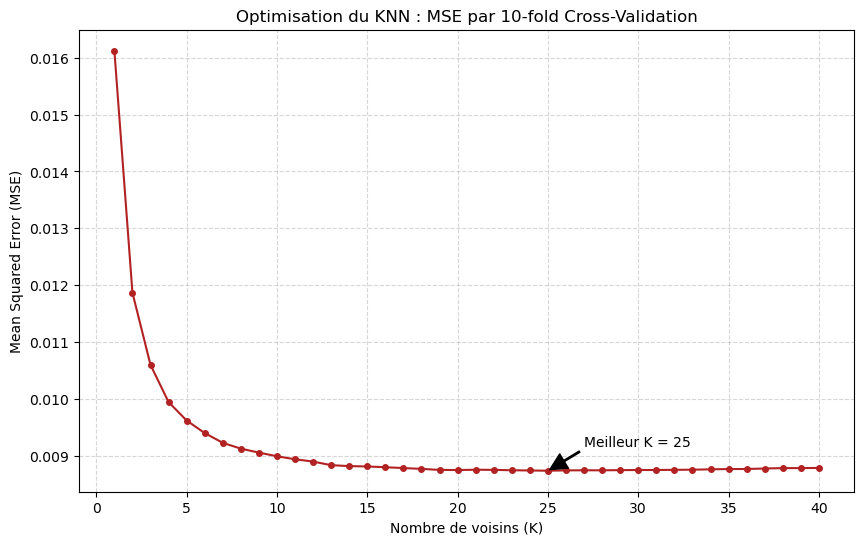

Le K optimal qui minimise la MSE est : 25
MSE minimale obtenue : 0.008734


In [17]:

# 1. Configuration de la recherche par validation croisée (10-fold CV)
# On définit une plage de K (ex: de 1 à 40)
param_grid = {'n_neighbors': np.arange(1, 41)}
knn_base = KNeighborsRegressor()

# GridSearchCV avec scoring='neg_mean_squared_error' pour mesurer la MSE
# cv=10 pour la 10-fold validation
grid_knn = GridSearchCV(knn_base, param_grid, cv=10, scoring='neg_mean_squared_error')
grid_knn.fit(X_train_scaled, y_train)

# 2. Extraction des résultats
results_df = pd.DataFrame(grid_knn.cv_results_)
# On convertit la Negative MSE en MSE positive pour le graphique
results_df['mse'] = -results_df['mean_test_score']

# 3. Création du graphique MSE en fonction de K
plt.figure(figsize=(10, 6))
plt.plot(results_df['param_n_neighbors'], results_df['mse'], 
         marker='o', linestyle='-', color='firebrick', markersize=4)

# Identification visuelle du meilleur K
best_k = grid_knn.best_params_['n_neighbors']
min_mse = results_df['mse'].min()

plt.annotate(f'Meilleur K = {best_k}', 
             xy=(best_k, min_mse), 
             xytext=(best_k + 2, min_mse + (min_mse*0.05)),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.title('Optimisation du KNN : MSE par 10-fold Cross-Validation')
plt.xlabel('Nombre de voisins (K)')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# 4. Affichage du résultat optimal
print(f"Le K optimal qui minimise la MSE est : {best_k}")
print(f"MSE minimale obtenue : {min_mse:.6f}")

# 5. Estimation finale sur l'ensemble Test
knn_final = grid_knn.best_estimator_
y_pred_knn = knn_final.predict(X_test_scaled)

## Arbre de décision

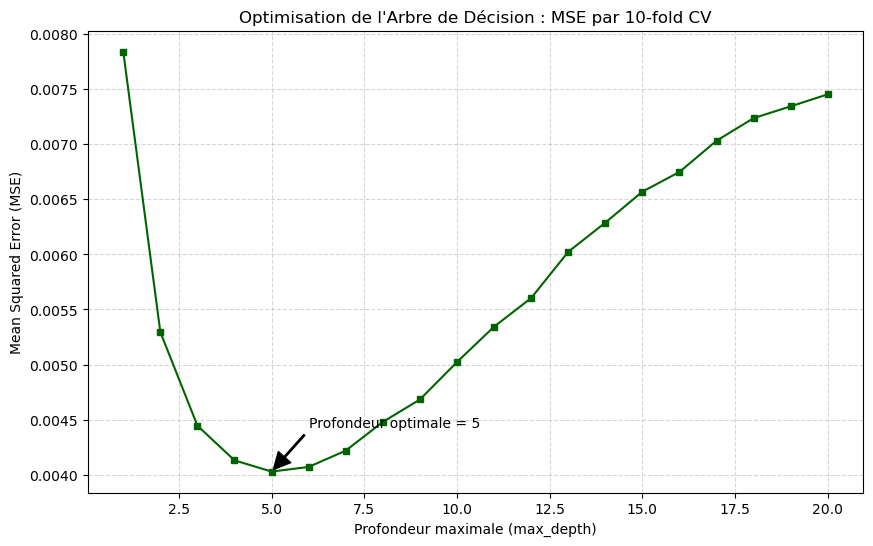

La profondeur optimale est : 5
MSE minimale (CV) : 0.004031


In [18]:

# Define the base decision tree model that was missing
tree_base = DecisionTreeRegressor(random_state=42)  # Added this line to define tree_base

# 1. Configuration de la recherche par validation croisée (10-fold CV)
# On optimise la profondeur maximale (max_depth) pour éviter le surapprentissage
param_grid_tree = {'max_depth': np.arange(1, 21)}

# GridSearchCV avec 10-fold CV sur la MSE
grid_tree = GridSearchCV(tree_base, param_grid_tree, cv=10, scoring='neg_mean_squared_error')
grid_tree.fit(X_train, y_train)

# 2. Extraction des résultats
results_tree_df = pd.DataFrame(grid_tree.cv_results_)
results_tree_df['mse'] = -results_tree_df['mean_test_score']

# 3. Création du graphique MSE en fonction de la profondeur
plt.figure(figsize=(10, 6))
plt.plot(results_tree_df['param_max_depth'], results_tree_df['mse'], 
         marker='s', linestyle='-', color='darkgreen', markersize=4)

# Identification de la profondeur optimale
best_depth = grid_tree.best_params_['max_depth']
min_mse_tree = results_tree_df['mse'].min()

plt.annotate(f'Profondeur optimale = {best_depth}', 
             xy=(best_depth, min_mse_tree), 
             xytext=(best_depth + 1, min_mse_tree + (min_mse_tree*0.1)),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.title('Optimisation de l\'Arbre de Décision : MSE par 10-fold CV')
plt.xlabel('Profondeur maximale (max_depth)')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# 4. Affichage du résultat optimal
print(f"La profondeur optimale est : {best_depth}")
print(f"MSE minimale (CV) : {min_mse_tree:.6f}")

# 5. Estimation finale sur l'ensemble Test
tree_final = grid_tree.best_estimator_
y_pred_tree = tree_final.predict(X_test)

## Comparaison des modèles

In [19]:

# --- 1. Entraînement des modèles sur l'ensemble Train ---

# A. OLS (Backward Selection - 17 variables identifiées précédemment)
features_backward = [
    'volatility_index', 'revenue', 'roa', 'roe', 'eps', 'momentum_12m', 
    'var_95', 'credit_spread', 'sector_Finance', 'sector_Healthcare', 
    'sector_Industry', 'sector_Technology', 'rating_category_AA', 
    'rating_category_AAA', 'rating_category_BB', 'rating_category_BBB'
]
X_train_ols = sm.add_constant(X_train[features_backward])
X_test_ols = sm.add_constant(X_test[features_backward])
model_ols = sm.OLS(y_train, X_train_ols.astype(float)).fit()

# B. KNN (K=25, nécessite les données scalées)
model_knn = KNeighborsRegressor(n_neighbors=25)
model_knn.fit(X_train_scaled, y_train)

# C. Decision Tree (Profondeur=5)
model_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
model_tree.fit(X_train, y_train)

# --- 2. Prédictions sur l'ensemble Test ---

y_pred_ols = model_ols.predict(X_test_ols)
y_pred_knn = model_knn.predict(X_test_scaled)
y_pred_tree = model_tree.predict(X_test)


In [20]:
# --- 3. Calcul et Affichage des Métriques de Performance ---

def get_metrics(y_true, y_pred, name):
    return {
        'Modèle': name,
        'R²': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred)
    }

metrics = [
    get_metrics(y_test, y_pred_ols, "OLS (Backward)"),
    get_metrics(y_test, y_pred_knn, "KNN (K=25)"),
    get_metrics(y_test, y_pred_tree, "Arbre (Prof=5)")
]

# Affichage sous forme de tableau comparatif
df_perf = pd.DataFrame(metrics).set_index('Modèle')
print("Comparaison des performances sur l'ensemble Test :")
display(df_perf.round(5))

Comparaison des performances sur l'ensemble Test :


,R²,RMSE,MAE
Modèle,,,
OLS (Backward),0.70972,0.06350,0.04534
KNN (K=25),0.36541,0.09389,0.07032
Arbre (Prof=5),0.70645,0.06386,0.04567


# 6. Discussion

Les performances de la régression linéaire (optimisée par sélection pas à pas) et de l'arbre de régression sont très similaires sur notre échantillon de test, affichant toutes deux un coefficient de détermination $R^2$ d'environ **0,71**. En revanche, la performance du modèle KNN est beaucoup plus faible, avec un $R^2$ d'uniquement **0,36**, ce qui nous conduit à l'exclure de nos choix de modélisation.

Le choix final se porte donc sur le modèle de **régression linéaire (avec sélection Backward)** pour plusieurs raisons fondamentales :
1. **Simplicité et efficacité :** Le modèle linéaire est beaucoup plus rapide à entraîner et ne nécessite pas l'optimisation d'hyperparamètres complexes par validation croisée.
2. **Parcimonie :** Grâce à la procédure de sélection, il n'utilise qu'un sous-ensemble de 16 variables (contre l'ensemble des données pour l'arbre), tout en conservant un pouvoir explicatif maximal.
3. **Interprétabilité économique :** Contrairement à l'arbre de décision qui peut agir comme une boîte noire, les coefficients de la régression linéaire permettent une lecture directe et quantitative des effets de chaque variable exogène sur le prix du marché (`market_price`).

Ainsi, pour répondre à notre problématique, le modèle linéaire avec sélection descendante constitue le meilleur compromis entre robustesse statistique, pouvoir prédictif et intelligibilité économique.